# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
#SEU CÓDIGO AQUI

In [3]:
# Importar Data Frame
base = pd.read_csv('CARRO_CLIENTES.csv')

In [4]:
base

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


In [5]:
# Verificar tipo de dados
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [6]:
# Verificar Nulos
base.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [7]:
# Remover coluna 'User ID'
base = base.drop(columns=['User ID'])

In [8]:
base.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


Todos os dados estão dentro do esperado para cada coluna

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [9]:
#SEU CÓDIGO AQUI

In [10]:
# Aplicar Label Encoder
le = LabelEncoder()

base['Gender_encoded'] = le.fit_transform(base['Gender'])

In [11]:
# Remover coluna categórica
base = base.drop(columns=['Gender'])

In [12]:
print(base[['Gender_encoded']].head())

   Gender_encoded
0               1
1               1
2               1
3               1
4               1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

In [13]:
#SEU CÓDIGO AQUI

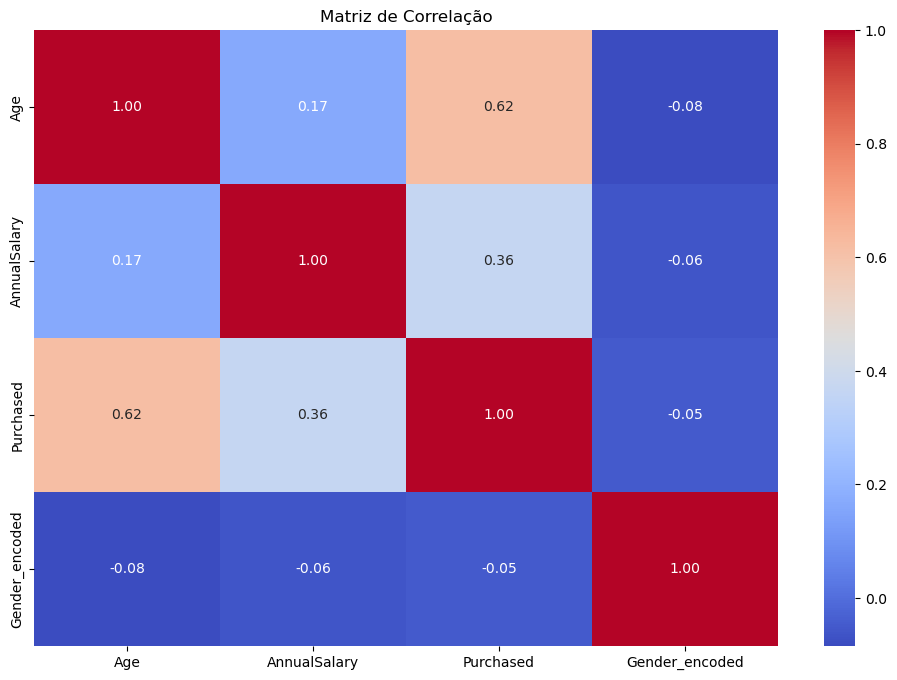

In [14]:
# Criar e visualizar Matriz de correlação
corr_matrix = base.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

- Age vs Purchased (0.62): há uma correlação positiva forte, indicando que a idade influencia significativamente a intenção de compra. Clientes mais velhos parecem ter maior probabilidade de comprar.
- AnnualSalary vs Purchased (0.36): correlação moderada, sugerindo que renda mais alta aumenta a chance de compra, mas não é o fator principal.
- Age vs AnnualSalary (0.17): relação fraca, mostrando que idade não explica bem a variação de salário na base.
- Gender_encoded apresenta correlações muito baixas com todas as variáveis (-0.05 a -0.08), indicando que gênero não tem impacto significativo sobre idade, salário ou intenção de compra neste conjunto de dados.

Portanto idade é o fator mais associado à compra online, seguido por renda, enquanto gênero praticamente não influencia. Isso sugere que campanhas podem ser mais eficazes se segmentadas por faixa etária e poder aquisitivo.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [15]:
#SEU CÓDIGO AQUI

In [16]:
# Definir X e y
X = base.drop(columns=['Purchased'])
y = base['Purchased']

# Separando em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [17]:
# Verificar os tamanhos
print("Tamanho treino:", X_train.shape, y_train.shape)
print("Tamanho teste:", X_test.shape, y_test.shape)

Tamanho treino: (700, 3) (700,)
Tamanho teste: (300, 3) (300,)


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [18]:
#SEU CÓDIGO AQUI

In [19]:
# Modelo com alguns hiperparâmetros
xgb_model = xgb.XGBClassifier(
    n_estimators=200,      # número de árvores
    max_depth=5,           # profundidade máxima
    learning_rate=0.1,     # taxa de aprendizado
    subsample=0.8,         # fração de amostras usadas por árvore
    colsample_bytree=0.8,  # fração de features usadas por árvore
    random_state=42
)

In [20]:
# Treinar o modelo
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [21]:
#SEU CÓDIGO AQUI

In [22]:
# Fazendo previsões
y_pred = xgb_model.predict(X_test)

In [23]:
# Probabilidades das previsões
y_pred_proba = xgb_model.predict_proba(X_test)

# Visualizando os primeiros resultados
print("Previsões (classes):", y_pred[:10])
print("Probabilidades (classe 0 e classe 1):")
print(y_pred_proba[:10])

Previsões (classes): [1 1 0 1 1 1 0 1 1 0]
Probabilidades (classe 0 e classe 1):
[[0.00452715 0.99547285]
 [0.01255965 0.98744035]
 [0.9824123  0.01758774]
 [0.3351431  0.6648569 ]
 [0.19419467 0.8058053 ]
 [0.00410014 0.99589986]
 [0.9884701  0.0115299 ]
 [0.07743913 0.9225609 ]
 [0.2574584  0.7425416 ]
 [0.8821814  0.11781856]]


# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [24]:
#SEU CÓDIGO AQUI

In [25]:
# Probabilidades da classe positiva (1)
y_pred_proba_bin = xgb_model.predict_proba(X_test)[:,1]

# Transformando em previsões binárias (threshold = 0.5)
y_pred_bin = (y_pred_proba_bin >= 0.5).astype(int)

# Conferindo os primeiros resultados
print("Probabilidades:", y_pred_proba_bin[:10])
print("Previsões binárias:", y_pred_bin[:10])

Probabilidades: [0.99547285 0.98744035 0.01758774 0.6648569  0.8058053  0.99589986
 0.0115299  0.9225609  0.7425416  0.11781856]
Previsões binárias: [1 1 0 1 1 1 0 1 1 0]


In [26]:
# Avaliação do desempenho
print("Acurácia:", accuracy_score(y_test, y_pred_bin))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_bin))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_bin))

Acurácia: 0.9033333333333333
Matriz de Confusão:
[[162  17]
 [ 12 109]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       179
           1       0.87      0.90      0.88       121

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



O modelo apresentou bom desempenho:
 - Acurácia de 90% mostra alta taxa de acertos gerais.
 - Matriz de confusão indica que a maioria dos compradores e não compradores foi corretamente classificada, com poucos erros.
 - Relatório de classificação confirma equilíbrio: precisão e recall próximos de 0.90 para ambas as classes, com F1-score consistente.

Portanto o modelo está bem ajustado e confiável, conseguindo distinguir compradores e não compradores de forma eficaz.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [27]:
#SEU CÓDIGO AQUI

In [28]:
# Pegar a importância das features
importance = xgb_model.feature_importances_

In [29]:
# Organizar e visualizar a importância das features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

          Feature  Importance
0             Age    0.467294
1    AnnualSalary    0.426571
2  Gender_encoded    0.106135


As features mais importantes manten-se as mesmas, porem AnnualSalary se mostrou muit mais proximo ao Age, do que verificado anteriorment em nivel de importancia.